[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link]
<a href="javascript:void(0);" onclick="openJupyterWidget('https://github.com/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-gcs/save_to_gcs.ipynb');">
    <img src="https://img.shields.io/badge/Open_in_JupyterHub-orange?style=for-the-badge" alt="JupyterHub Badge">
</a> [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link]

[download-link]: https://nmfs-opensci.github.io/NMFSHackDays-2025/topics-2025/2025-gcs/save_to_gcs.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-gcs/save_to_gcs.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/nmfshackdays-2025/main/topics-2025/2025-gcs/save_to_gcs.ipynb

# Uploading to Google Cloud

### Prerequisites

The `py-rocket-geospatial-2` image on the NMFS Openscapes JuptyerHub is already set up with this.

* `pip install google-cloud-storage`
* `sudo apt-get install google-cloud-sdk`

You need to have the Storage Admin role on the bucket or on the folder of a bucket. For example, if you will be uploading to the [NOAA Fisheries Google NODD Public Buckets](https://www.noaa.gov/nodd/datasets#NMFS), you will need to be added as a Storage Admin role to a specific folder.

## Authenticate

Run the following in a terminal. It will open and you authenticate there. It will save `application_default_credentials.json` to `~/.config/gcloud`. If you do not have `google-cloud-sdk` installed, you can install somewhere (like locally) and then copy that file and create it here (in hub or whereever you are running this tutorial).

## Upload a netcdf file

The code to create `littlecube.nc` is below.

In [7]:
# set up bucket client
# stop annoying warnings
import warnings
warnings.filterwarnings("ignore", message="Your application has authenticated using end user credentials")

from google.cloud import storage
from pathlib import Path

# === Set these ===
bucket_name = "nmfs_odp_nwfsc"

# Create client and bucket
client = storage.Client(project="noaa-gcs-public-data")
bucket = client.bucket(bucket_name)

## Upload a netcdf file

The code to create `littlecube.nc` is below.

In [8]:
# Set the file you want to test with
test_file = Path("littlecube.nc")  # change this if using a different file
destination_prefix = "CB/test"

# Create blob and upload
blob_path = f"{destination_prefix}/{test_file.name}"
blob = bucket.blob(blob_path)
blob.upload_from_filename(str(test_file))

print(f"Uploaded {test_file.name} → gs://{bucket_name}/{blob_path}")

Uploaded littlecube.nc → gs://nmfs_odp_nwfsc/CB/test/littlecube.nc


### Lazy loading one file

In [14]:
import xarray as xr
import fsspec
url = "gcs://nmfs_odp_nwfsc/CB/test/littlecube.nc"
fs = fsspec.filesystem("gcs", anon=True) # anon=True since this is a public bucket
f = fs.open(url, mode="rb") # Open file
ds = xr.open_dataset(f)  # lazy load

In [10]:
ds

<xarray.Dataset> Size: 8kB
Dimensions:       (lat: 8, lon: 8, time: 31)
Coordinates:
  * lat           (lat) float32 32B 33.62 33.88 34.12 ... 34.88 35.12 35.38
  * lon           (lon) float32 32B -75.38 -75.12 -74.88 ... -73.88 -73.62
  * time          (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    analysed_sst  (time, lat, lon) float32 8kB ...

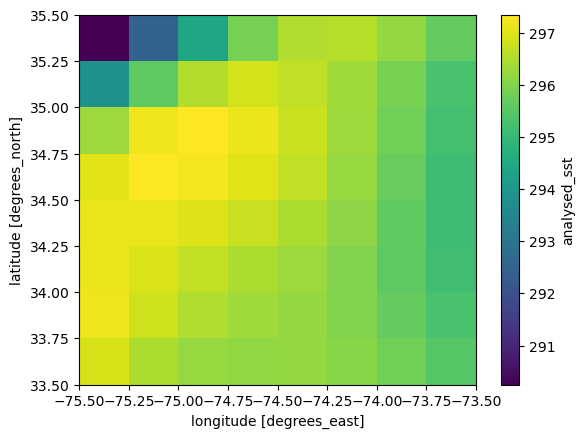

In [18]:
ds["analysed_sst"].mean(dim="time").plot()

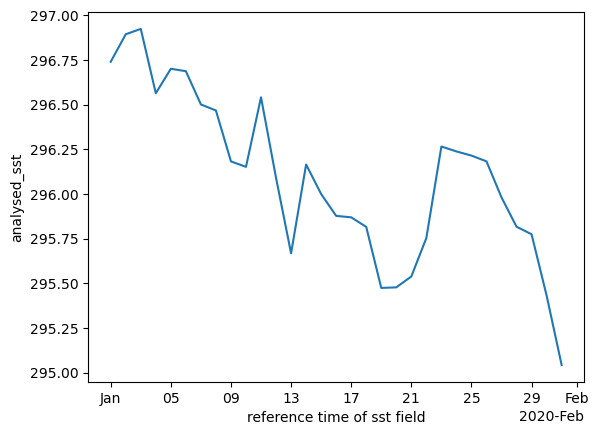

In [20]:
ds["analysed_sst"].mean(dim=["lat", "lon"]).plot()

In [19]:
# when completely done
f.close() # close the file when you're completely done

## Summary

We uploaded netcdf and Zarr directory to Google Cloud. Some workflows are based on downloading netcdf files, so I uploaded those but if you want to interact with the data by only getting the subsets that you need, then you will want to work with the Zarr files. Unfortunately, R tooling does not yet work well with Zarr files, but it is catching up.

In [ ]:
import gcsfs

fs = gcsfs.GCSFileSystem(token="/home/jovyan/.config/gcloud/application_default_credentials.json")

bucket_prefix = "nmfs_odp_nwfsc/CB/nwm_daily_means/wr18"

# List all files under the prefix
files = fs.ls(bucket_prefix)

# Delete each file
for f in files:
    print(f"Deleting {f}")
    fs.rm(f, recursive=True)

print("✅ Folder deleted.")

# Create a test file

In [3]:
import earthaccess
short_name = 'AVHRR_OI-NCEI-L4-GLOB-v2.1'
version = "2.1"
date_range = ("2020-01-02", "2020-01-31")

results = earthaccess.search_data(
    short_name = short_name,
    version = version,
    temporal = date_range,
    cloud_hosted=True
)
fileset = earthaccess.open(results)
import xarray as xr
ds = xr.open_mfdataset(fileset)
dc = ds['analysed_sst'].sel(lat=slice(33.5, 35.5), lon=slice(-75.5, -73.5)) 
dc.to_netcdf("littlecube.nc")

31